In [1]:
import os
import help
from help import prepare_dataset, test_on_data, plot_train_history, plot_confusion_matrix
from help import vgg_model, resnet_model, cv_train_and_evaluate_model, train_and_evaluate_model, cv_train_model, cv_train_vgg_model, imbalanced_cv_train_and_evaluate_model


2024-12-28 21:26:12.984953: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-28 21:26:14.435991: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-28 21:26:14.436094: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-28 21:26:14.438011: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-28 21:26:15.402584: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-28 21:26:15.404332: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

In [2]:
help.sns.set_theme()
path_dir = help.os.getcwd()
help.np.random.seed(123)
help.tf.random.set_seed(123)


# Train on Selected Data

In [3]:
path_dir = r"/users/PCS0229/imankhazrak/DDPM_L/Classification/with_without"
dataset_dir_org = f'{path_dir}/Original'


In [4]:
class_labels = sorted(os.listdir(dataset_dir_org))
print('class_labels: ', class_labels)
num_classes = len(class_labels)
print('Number of classes= ', num_classes)
input_shape=(128, 128, 3)

cv=1
epochs=20
batch_size=32
n = 1 # number of different runs

class_labels:  ['With structural pathology', 'Without structural pathology']
Number of classes=  2


In [19]:
import os

def remove_desktop_ini(root_dir):
    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.lower() == "desktop.ini":
                file_path = os.path.join(root, file)
                try:
                    os.remove(file_path)
                    print(f"Removed: {file_path}")
                except Exception as e:
                    print(f"Error removing {file_path}: {e}")

# # Replace 'path_to_images' with the path to your image folders
# path_to_images = "path_to_your_image_folders"
# remove_desktop_ini(path_to_images)

dataset_dir_org = f'{path_dir}/Original'
dataset_dir_ddpm = f'{path_dir}/Generated'
remove_desktop_ini(dataset_dir_org)
remove_desktop_ini(dataset_dir_ddpm)
dataset_dir_org = f'{path_dir}/10_percent/Original'
dataset_dir_ddpm = f'{path_dir}/10_percent/Generated'
remove_desktop_ini(dataset_dir_org)
remove_desktop_ini(dataset_dir_ddpm)
dataset_dir_org = f'{path_dir}/50_percent/Original'
dataset_dir_ddpm = f'{path_dir}/50_percent/Generated'
remove_desktop_ini(dataset_dir_org)
remove_desktop_ini(dataset_dir_ddpm)

## Untrained VGG16

#### Train on just Syn test of all Original Dataset

Class labels:  ['With structural pathology', 'Without structural pathology']


2024-12-28 02:18:30.918250: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
105/105 [==============================] - 32s 299ms/step - loss: 0.3652 - accuracy: 0.8813 - val_loss: 0.2406 - val_accuracy: 0.9079
Epoch 2/100
105/105 [==============================] - 32s 305ms/step - loss: 0.2529 - accuracy: 0.9055 - val_loss: 0.2438 - val_accuracy: 0.9079
Epoch 3/100
105/105 [==============================] - 32s 308ms/step - loss: 0.2611 - accuracy: 0.9040 - val_loss: 0.2455 - val_accuracy: 0.9079
Epoch 4/100
105/105 [==============================] - 32s 308ms/step - loss: 0.2391 - accuracy: 0.9079 - val_loss: 0.2244 - val_accuracy: 0.9079
Epoch 5/100
105/105 [==============================] - 32s 309ms/step - loss: 0.2312 - accuracy: 0.9118 - val_loss: 0.2625 - val_accuracy: 0.9079
Epoch 6/100
105/105 [==============================] - 33s 310ms/step - loss: 0.2287 - accuracy: 0.9076 - val_loss: 0.2436 - val_accuracy: 0.9079
Epoch 7/100
105/105 [==============================] - 32s 308ms/step - loss: 0.2297 - accuracy: 0.9103 - val_loss: 0.2170 -

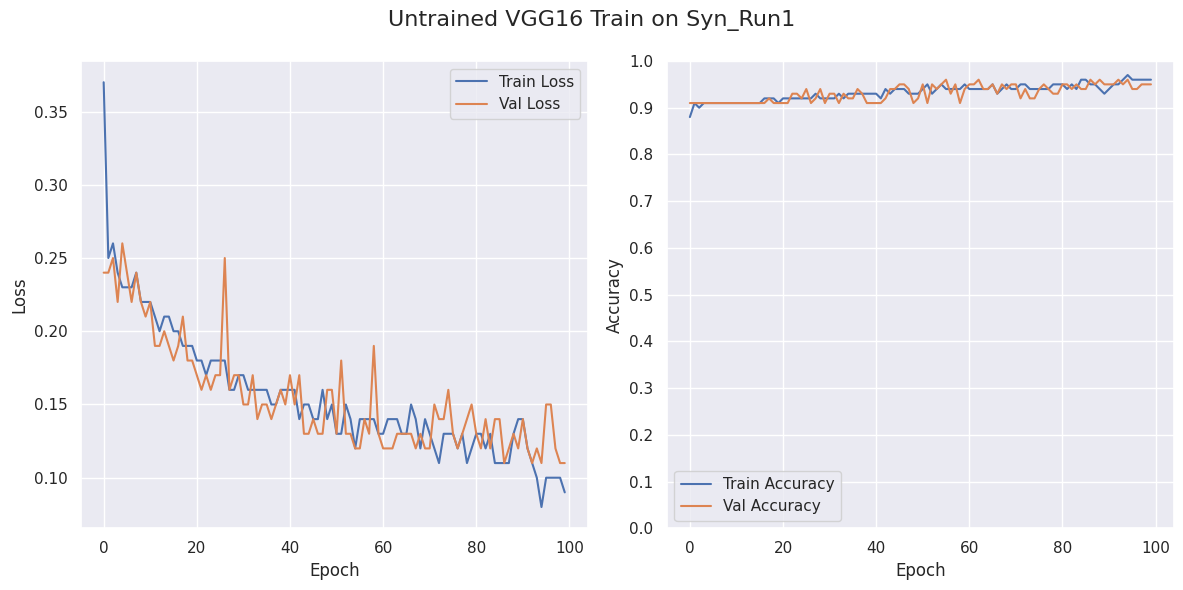

13/13 [==============================] - 3s 219ms/step
{'Test Loss': 1.2166, 'Test Accuracy': 0.703, 'F1 Score': 0.66, 'Sensitivity (Recall)': 0.7, 'Precision': 0.73, 'Specificity (With Structural Pathology)': 0.3057324840764331}


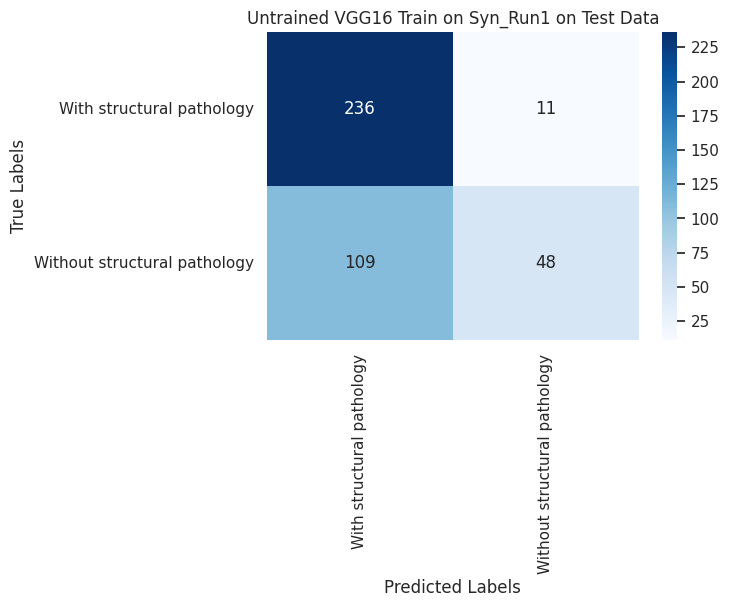

Class labels:  ['With structural pathology', 'Without structural pathology']
Epoch 1/100
105/105 [==============================] - 32s 298ms/step - loss: 0.3795 - accuracy: 0.8810 - val_loss: 0.2588 - val_accuracy: 0.9079
Epoch 2/100
105/105 [==============================] - 32s 301ms/step - loss: 0.2520 - accuracy: 0.9064 - val_loss: 0.2316 - val_accuracy: 0.9079
Epoch 3/100
105/105 [==============================] - 31s 301ms/step - loss: 0.2497 - accuracy: 0.9064 - val_loss: 0.2609 - val_accuracy: 0.9079
Epoch 4/100
105/105 [==============================] - 31s 300ms/step - loss: 0.2355 - accuracy: 0.9064 - val_loss: 0.2212 - val_accuracy: 0.9079
Epoch 5/100
105/105 [==============================] - 32s 302ms/step - loss: 0.2282 - accuracy: 0.9097 - val_loss: 0.2490 - val_accuracy: 0.9079
Epoch 6/100
105/105 [==============================] - 32s 301ms/step - loss: 0.2297 - accuracy: 0.9082 - val_loss: 0.2496 - val_accuracy: 0.9079
Epoch 7/100
105/105 [==========================

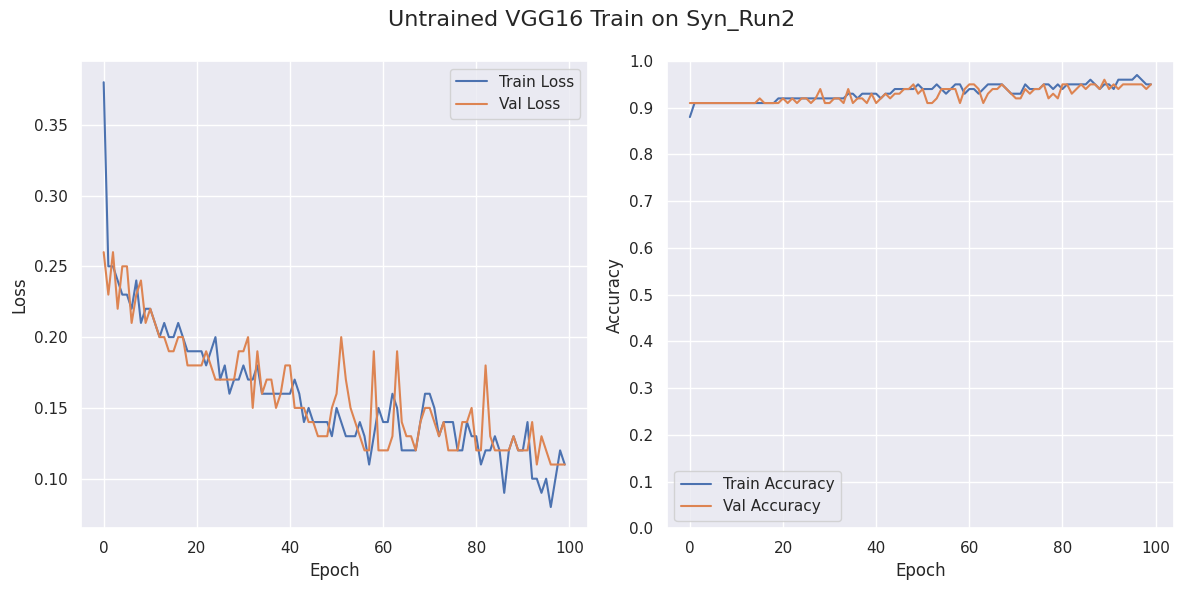

13/13 [==============================] - 3s 219ms/step
{'Test Loss': 1.0529, 'Test Accuracy': 0.6955, 'F1 Score': 0.64, 'Sensitivity (Recall)': 0.7, 'Precision': 0.74, 'Specificity (With Structural Pathology)': 0.2611464968152866}


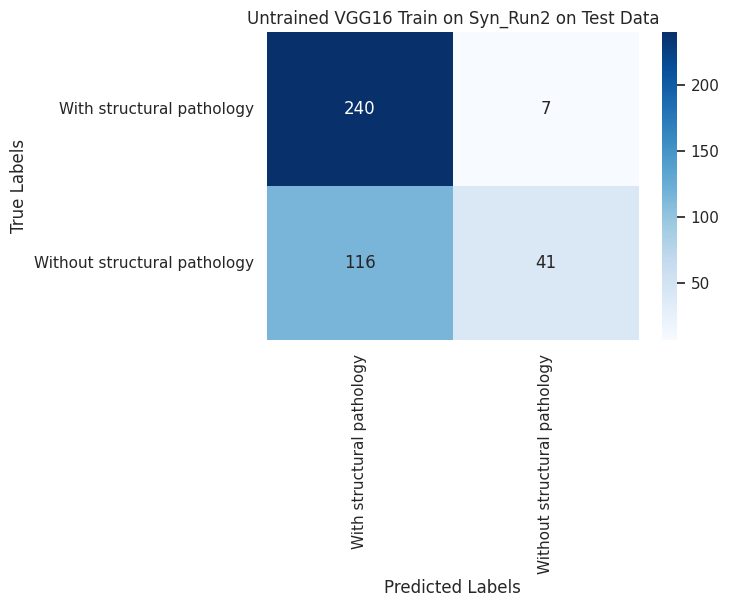

Class labels:  ['With structural pathology', 'Without structural pathology']
Epoch 1/100
105/105 [==============================] - 32s 296ms/step - loss: 0.4307 - accuracy: 0.8756 - val_loss: 0.2379 - val_accuracy: 0.9079
Epoch 2/100
105/105 [==============================] - 31s 299ms/step - loss: 0.2622 - accuracy: 0.9067 - val_loss: 0.2479 - val_accuracy: 0.9079
Epoch 3/100
105/105 [==============================] - 31s 299ms/step - loss: 0.2578 - accuracy: 0.9073 - val_loss: 0.2569 - val_accuracy: 0.9079
Epoch 4/100
105/105 [==============================] - 31s 300ms/step - loss: 0.2497 - accuracy: 0.9082 - val_loss: 0.2315 - val_accuracy: 0.9079
Epoch 5/100
105/105 [==============================] - 31s 300ms/step - loss: 0.2468 - accuracy: 0.9085 - val_loss: 0.2370 - val_accuracy: 0.9079
Epoch 6/100
105/105 [==============================] - 32s 301ms/step - loss: 0.2427 - accuracy: 0.9076 - val_loss: 0.2584 - val_accuracy: 0.9079
Epoch 7/100
105/105 [==========================

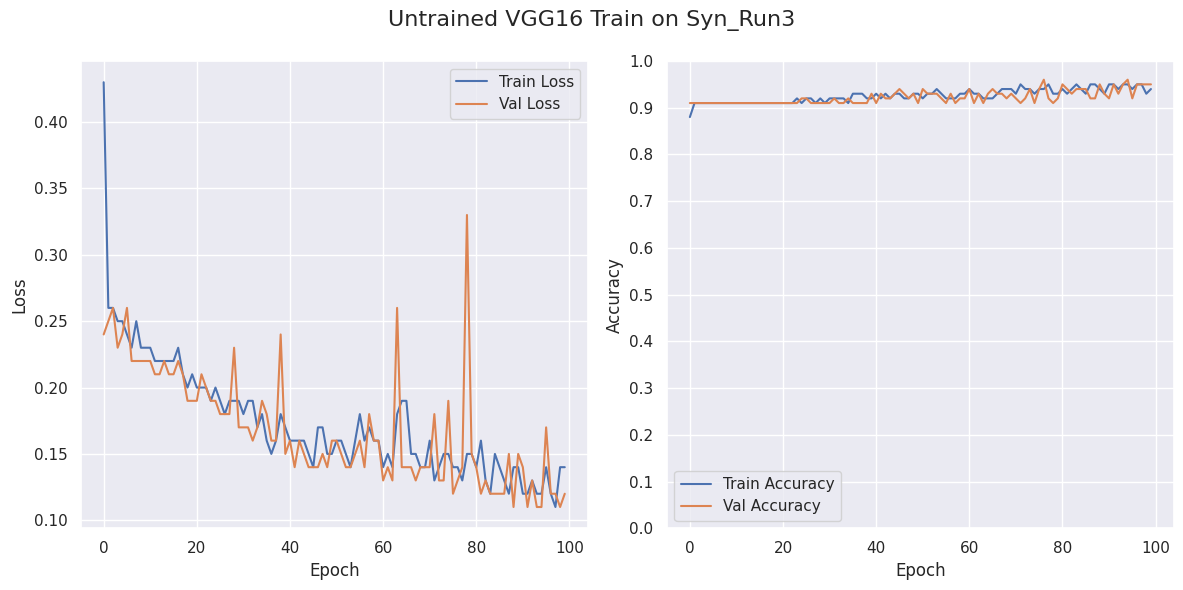

13/13 [==============================] - 3s 219ms/step
{'Test Loss': 1.3346, 'Test Accuracy': 0.6361, 'F1 Score': 0.53, 'Sensitivity (Recall)': 0.64, 'Precision': 0.69, 'Specificity (With Structural Pathology)': 0.08917197452229299}


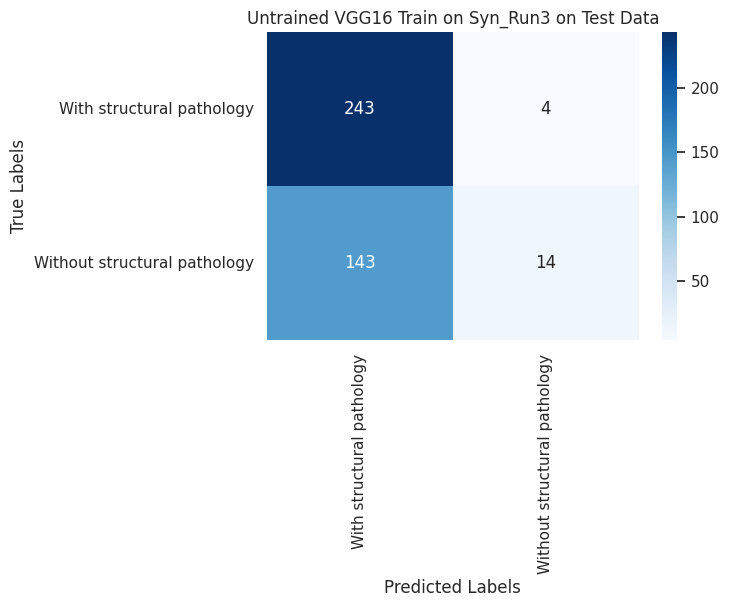

Class labels:  ['With structural pathology', 'Without structural pathology']
Epoch 1/100
105/105 [==============================] - 32s 299ms/step - loss: 0.3620 - accuracy: 0.8828 - val_loss: 0.2627 - val_accuracy: 0.9079
Epoch 2/100
105/105 [==============================] - 32s 301ms/step - loss: 0.2512 - accuracy: 0.9052 - val_loss: 0.2493 - val_accuracy: 0.9079
Epoch 3/100
105/105 [==============================] - 32s 303ms/step - loss: 0.2511 - accuracy: 0.9061 - val_loss: 0.2551 - val_accuracy: 0.9079
Epoch 4/100
105/105 [==============================] - 32s 301ms/step - loss: 0.2348 - accuracy: 0.9085 - val_loss: 0.2196 - val_accuracy: 0.9079
Epoch 5/100
105/105 [==============================] - 32s 302ms/step - loss: 0.2333 - accuracy: 0.9091 - val_loss: 0.2410 - val_accuracy: 0.9079
Epoch 6/100
105/105 [==============================] - 31s 300ms/step - loss: 0.2312 - accuracy: 0.9079 - val_loss: 0.2736 - val_accuracy: 0.9079
Epoch 7/100
105/105 [==========================

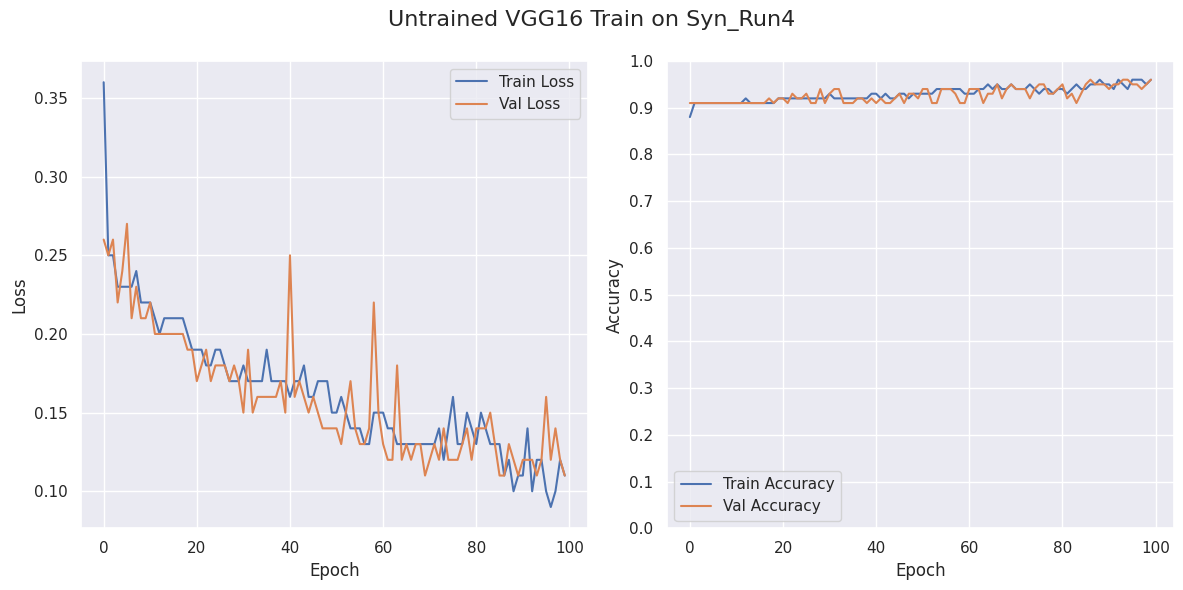

13/13 [==============================] - 3s 218ms/step
{'Test Loss': 0.9909, 'Test Accuracy': 0.6782, 'F1 Score': 0.62, 'Sensitivity (Recall)': 0.68, 'Precision': 0.72, 'Specificity (With Structural Pathology)': 0.2229299363057325}


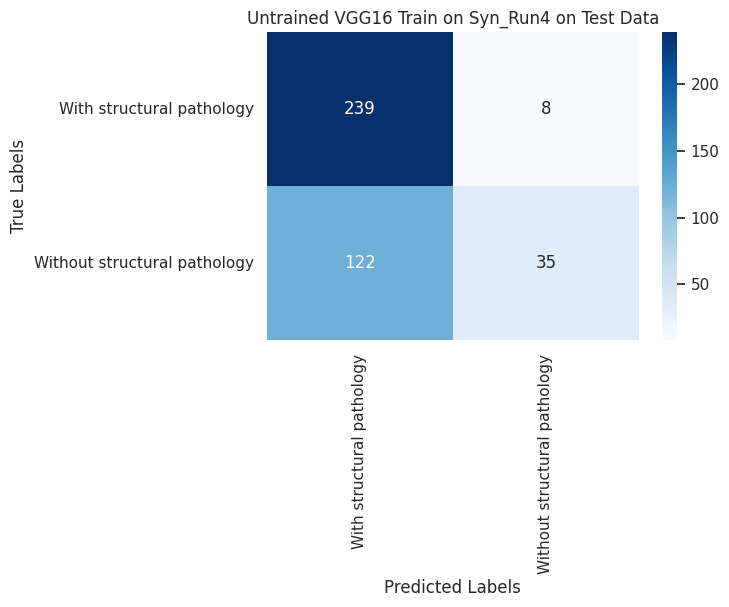

Class labels:  ['With structural pathology', 'Without structural pathology']
Epoch 1/100
105/105 [==============================] - 32s 295ms/step - loss: 0.4022 - accuracy: 0.8831 - val_loss: 0.2835 - val_accuracy: 0.9079
Epoch 2/100
105/105 [==============================] - 31s 297ms/step - loss: 0.2607 - accuracy: 0.9079 - val_loss: 0.2498 - val_accuracy: 0.9079
Epoch 3/100
105/105 [==============================] - 31s 298ms/step - loss: 0.2640 - accuracy: 0.9085 - val_loss: 0.2566 - val_accuracy: 0.9079
Epoch 4/100
105/105 [==============================] - 31s 298ms/step - loss: 0.2451 - accuracy: 0.9085 - val_loss: 0.2258 - val_accuracy: 0.9079
Epoch 5/100
105/105 [==============================] - 31s 299ms/step - loss: 0.2379 - accuracy: 0.9106 - val_loss: 0.2671 - val_accuracy: 0.9079
Epoch 6/100
105/105 [==============================] - 31s 298ms/step - loss: 0.2387 - accuracy: 0.9082 - val_loss: 0.2799 - val_accuracy: 0.9079
Epoch 7/100
105/105 [==========================

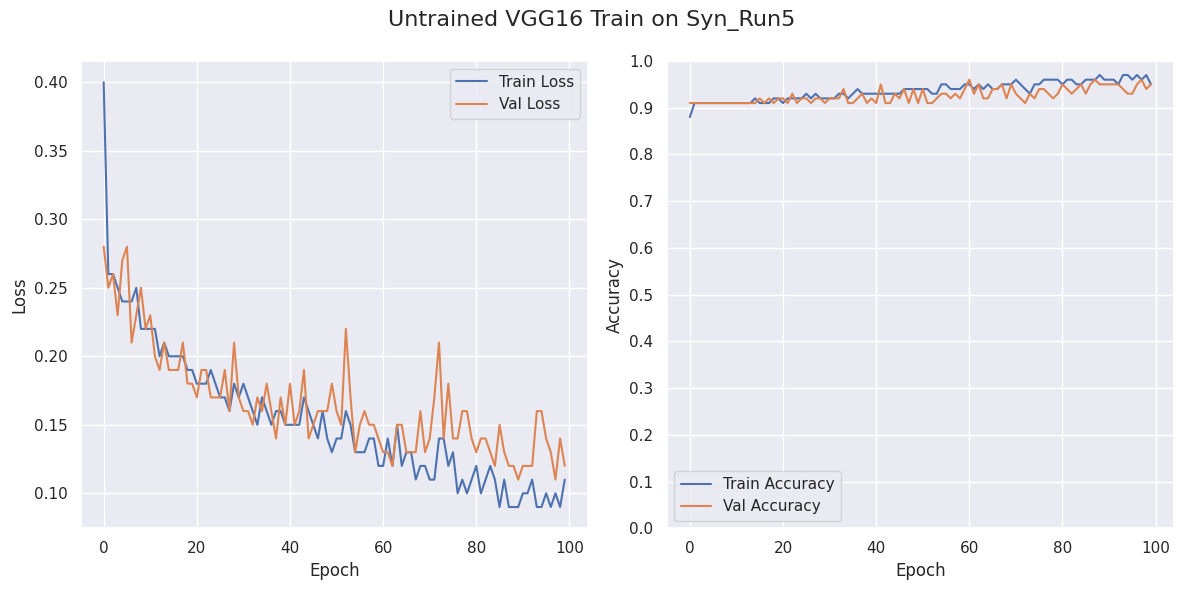

13/13 [==============================] - 3s 222ms/step
{'Test Loss': 1.291, 'Test Accuracy': 0.6708, 'F1 Score': 0.6, 'Sensitivity (Recall)': 0.67, 'Precision': 0.74, 'Specificity (With Structural Pathology)': 0.17834394904458598}


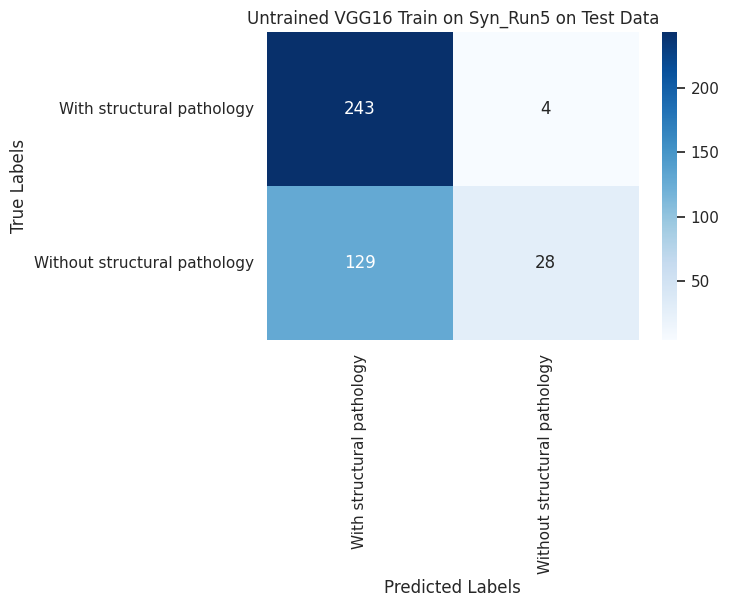

In [5]:
dataset_dir_org = f'{path_dir}/Original'
dataset_dir_ddpm = f'{path_dir}/Generated'

title = "Untrained VGG16 Train on Syn"
file_name = f"{path_dir}/Trained_Models/Untrained_VGG16_Synthetic.png"

epochs=100
n=5

for i in range(0, n):
    trained_model, test_metrics, confusion_matrix = cv_train_and_evaluate_model(
        dataset_dir_ddpm,
        dataset_dir_org,
        class_labels,
        vgg_model,
        weights=None,
        input_shape=input_shape,
        title=f"{title}_Run{i+1}",
        file_name=file_name,  # Now treated as a keyword argument
        cv=cv,
        epochs=epochs,
        batch_size=batch_size
    )

#### Train on Syn + 10 percent of Original Dataset

Class labels:  ['With structural pathology', 'Without structural pathology']


2024-12-28 11:58:24.479839: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
106/106 [==============================] - 33s 300ms/step - loss: 0.4216 - accuracy: 0.8759 - val_loss: 0.2639 - val_accuracy: 0.9053
Epoch 2/100
106/106 [==============================] - 32s 301ms/step - loss: 0.2889 - accuracy: 0.9031 - val_loss: 0.2479 - val_accuracy: 0.9053
Epoch 3/100
106/106 [==============================] - 32s 304ms/step - loss: 0.2717 - accuracy: 0.9031 - val_loss: 0.2452 - val_accuracy: 0.9053
Epoch 4/100
106/106 [==============================] - 32s 305ms/step - loss: 0.2574 - accuracy: 0.9055 - val_loss: 0.2517 - val_accuracy: 0.9053
Epoch 5/100
106/106 [==============================] - 32s 305ms/step - loss: 0.2617 - accuracy: 0.9043 - val_loss: 0.2513 - val_accuracy: 0.9053
Epoch 6/100
106/106 [==============================] - 32s 304ms/step - loss: 0.2476 - accuracy: 0.9040 - val_loss: 0.2240 - val_accuracy: 0.9053
Epoch 7/100
106/106 [==============================] - 32s 305ms/step - loss: 0.2506 - accuracy: 0.9046 - val_loss: 0.2327 -

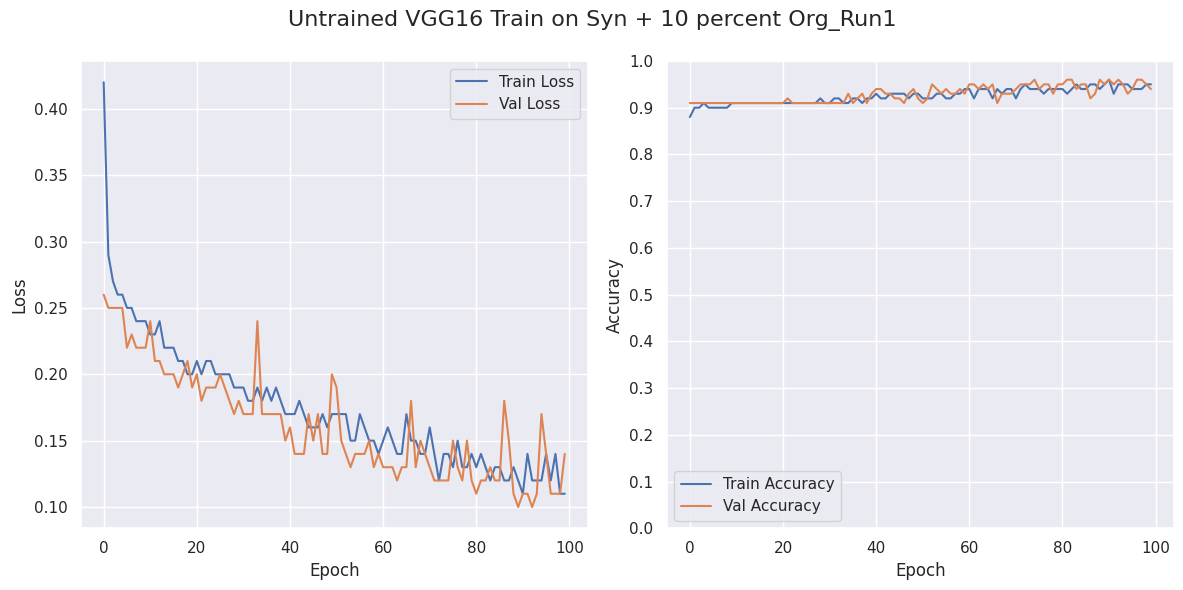

12/12 [==============================] - 3s 211ms/step
{'Test Loss': 1.4631, 'Test Accuracy': 0.6391, 'F1 Score': 0.53, 'Sensitivity (Recall)': 0.64, 'Precision': 0.74, 'Specificity (With Structural Pathology)': 0.07801418439716312}


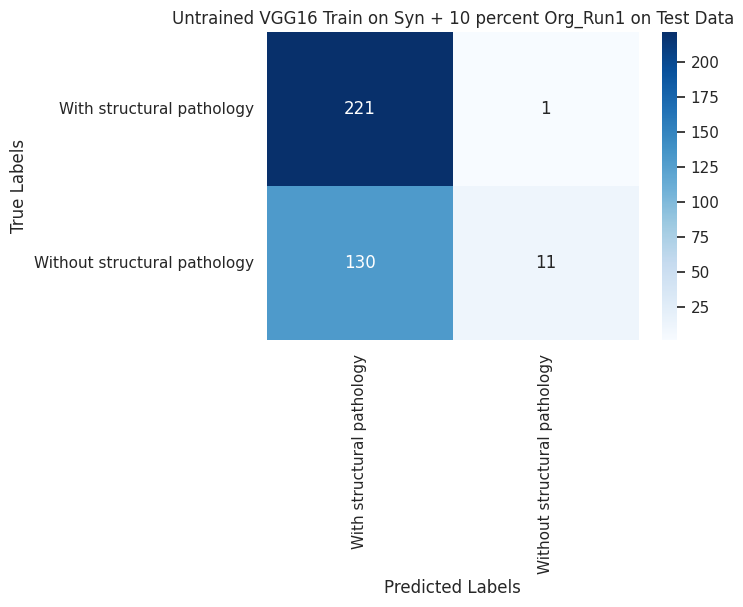

Class labels:  ['With structural pathology', 'Without structural pathology']
Epoch 1/100
106/106 [==============================] - 32s 295ms/step - loss: 0.3527 - accuracy: 0.8877 - val_loss: 0.2786 - val_accuracy: 0.9053
Epoch 2/100
106/106 [==============================] - 32s 298ms/step - loss: 0.2755 - accuracy: 0.9023 - val_loss: 0.2432 - val_accuracy: 0.9053
Epoch 3/100
106/106 [==============================] - 32s 298ms/step - loss: 0.2575 - accuracy: 0.9034 - val_loss: 0.2371 - val_accuracy: 0.9053
Epoch 4/100
106/106 [==============================] - 32s 300ms/step - loss: 0.2483 - accuracy: 0.9055 - val_loss: 0.2349 - val_accuracy: 0.9053
Epoch 5/100
106/106 [==============================] - 32s 300ms/step - loss: 0.2462 - accuracy: 0.9073 - val_loss: 0.2314 - val_accuracy: 0.9101
Epoch 6/100
106/106 [==============================] - 32s 300ms/step - loss: 0.2409 - accuracy: 0.9052 - val_loss: 0.2203 - val_accuracy: 0.9053
Epoch 7/100
106/106 [==========================

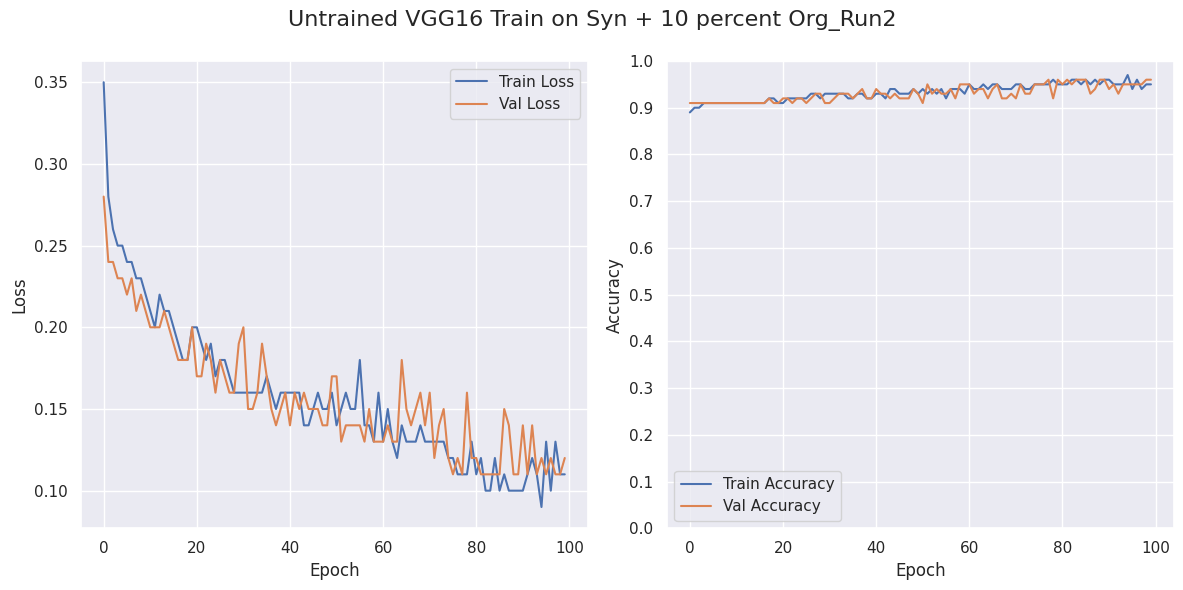

12/12 [==============================] - 3s 213ms/step
{'Test Loss': 1.0899, 'Test Accuracy': 0.6639, 'F1 Score': 0.58, 'Sensitivity (Recall)': 0.66, 'Precision': 0.73, 'Specificity (With Structural Pathology)': 0.16312056737588654}


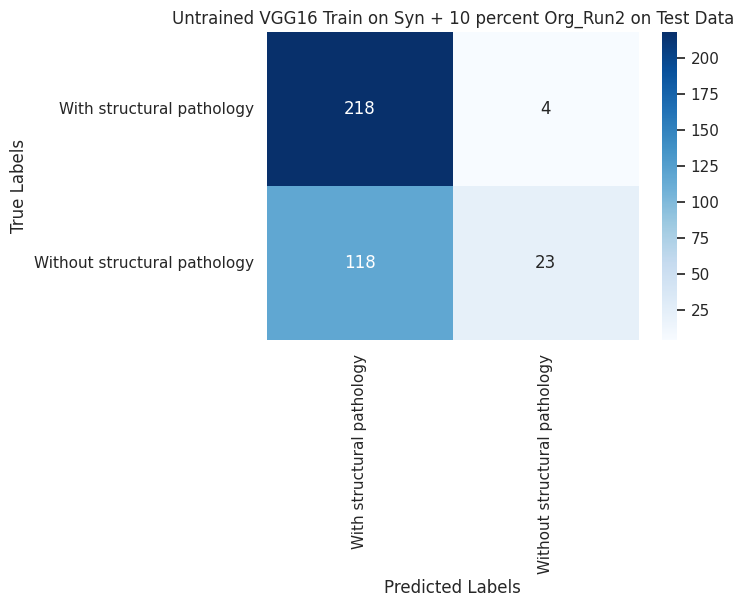

Class labels:  ['With structural pathology', 'Without structural pathology']
Epoch 1/100
106/106 [==============================] - 32s 293ms/step - loss: 0.3769 - accuracy: 0.8794 - val_loss: 0.2535 - val_accuracy: 0.9053
Epoch 2/100
106/106 [==============================] - 32s 298ms/step - loss: 0.2682 - accuracy: 0.9017 - val_loss: 0.2364 - val_accuracy: 0.9053
Epoch 3/100
106/106 [==============================] - 32s 300ms/step - loss: 0.2553 - accuracy: 0.9043 - val_loss: 0.2318 - val_accuracy: 0.9053
Epoch 4/100
106/106 [==============================] - 32s 299ms/step - loss: 0.2475 - accuracy: 0.9040 - val_loss: 0.2344 - val_accuracy: 0.9053
Epoch 5/100
106/106 [==============================] - 32s 301ms/step - loss: 0.2415 - accuracy: 0.9034 - val_loss: 0.2433 - val_accuracy: 0.9112
Epoch 6/100
106/106 [==============================] - 32s 300ms/step - loss: 0.2309 - accuracy: 0.9064 - val_loss: 0.2141 - val_accuracy: 0.9053
Epoch 7/100
106/106 [==========================

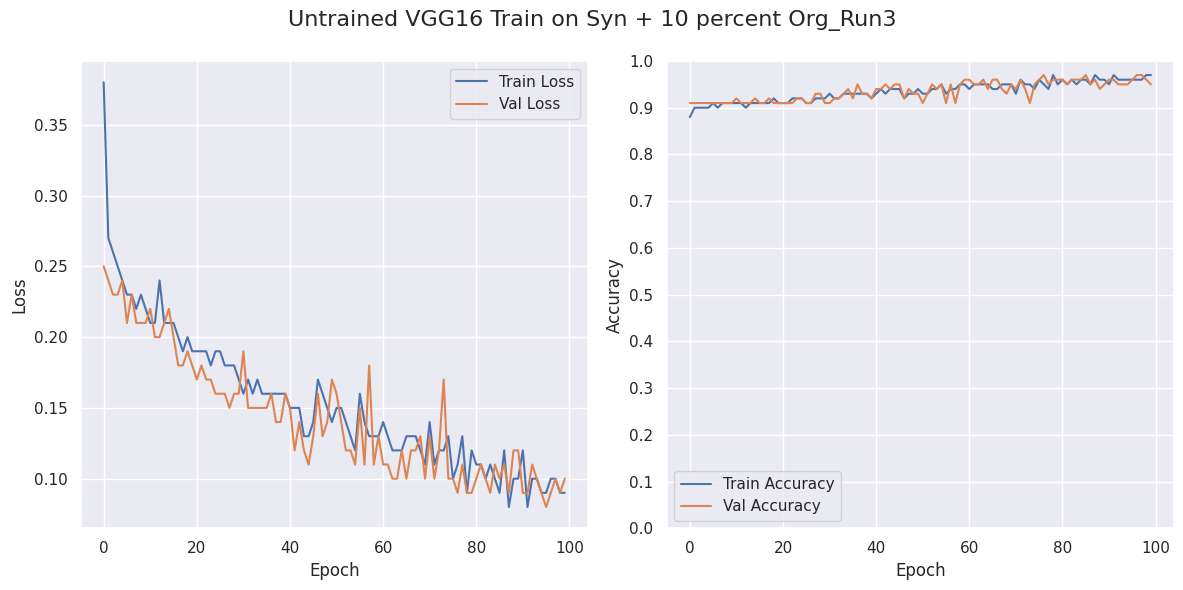

12/12 [==============================] - 3s 208ms/step
{'Test Loss': 1.5012, 'Test Accuracy': 0.6584, 'F1 Score': 0.57, 'Sensitivity (Recall)': 0.66, 'Precision': 0.74, 'Specificity (With Structural Pathology)': 0.1347517730496454}


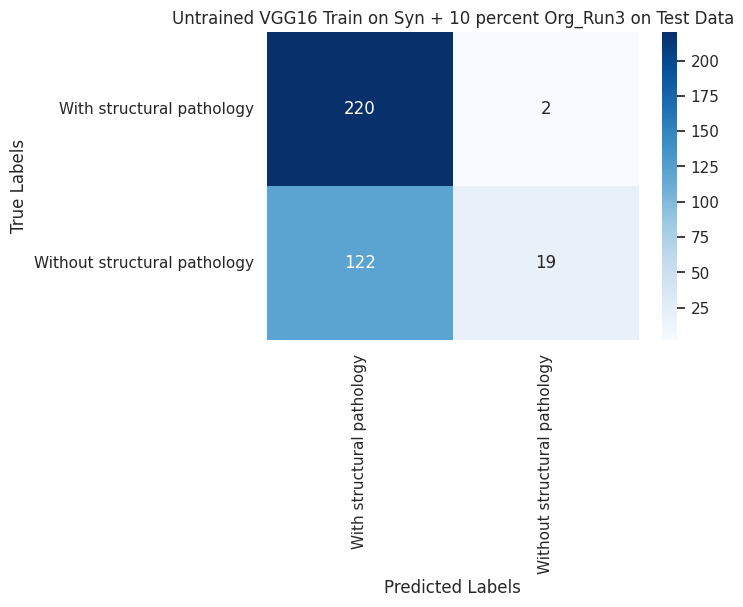

Class labels:  ['With structural pathology', 'Without structural pathology']
Epoch 1/100
106/106 [==============================] - 32s 293ms/step - loss: 0.3991 - accuracy: 0.8774 - val_loss: 0.2591 - val_accuracy: 0.9053
Epoch 2/100
106/106 [==============================] - 31s 295ms/step - loss: 0.2738 - accuracy: 0.9014 - val_loss: 0.2453 - val_accuracy: 0.9053
Epoch 3/100
106/106 [==============================] - 31s 295ms/step - loss: 0.2641 - accuracy: 0.9028 - val_loss: 0.2393 - val_accuracy: 0.9053
Epoch 4/100
106/106 [==============================] - 31s 296ms/step - loss: 0.2501 - accuracy: 0.9034 - val_loss: 0.2435 - val_accuracy: 0.9053
Epoch 5/100
106/106 [==============================] - 31s 296ms/step - loss: 0.2467 - accuracy: 0.9064 - val_loss: 0.2364 - val_accuracy: 0.9053
Epoch 6/100
106/106 [==============================] - 31s 295ms/step - loss: 0.2348 - accuracy: 0.9079 - val_loss: 0.2204 - val_accuracy: 0.9053
Epoch 7/100
106/106 [==========================

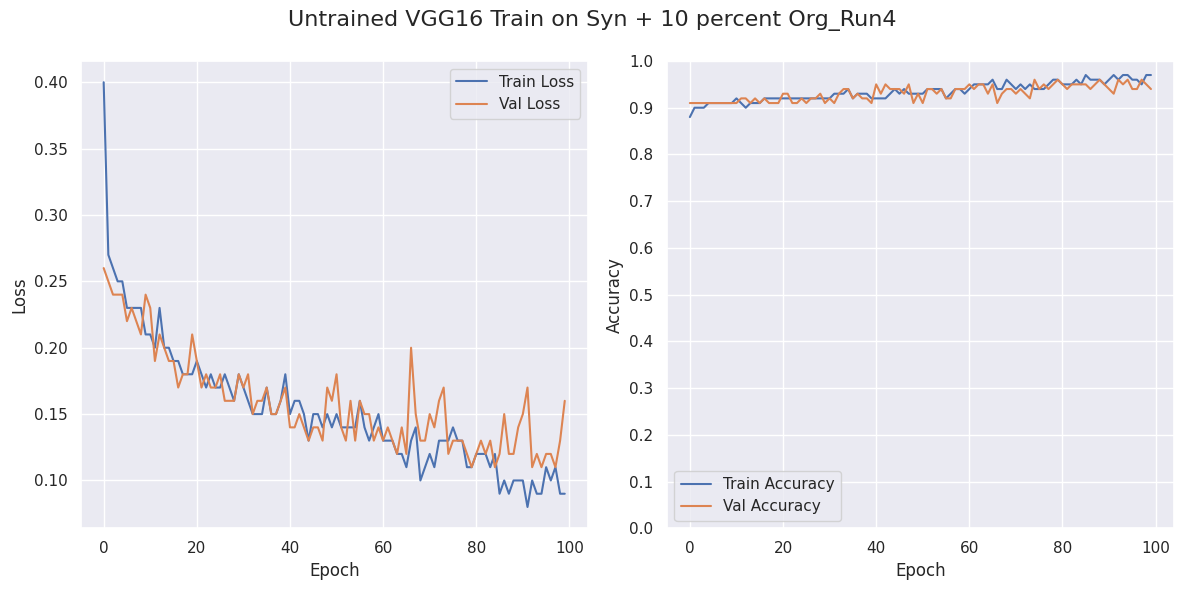

12/12 [==============================] - 3s 210ms/step
{'Test Loss': 1.5509, 'Test Accuracy': 0.6446, 'F1 Score': 0.54, 'Sensitivity (Recall)': 0.64, 'Precision': 0.75, 'Specificity (With Structural Pathology)': 0.09219858156028368}


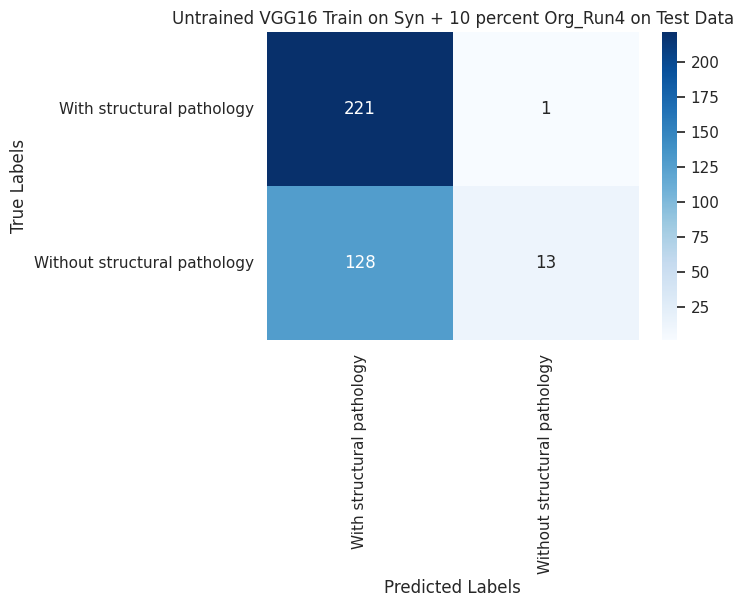

Class labels:  ['With structural pathology', 'Without structural pathology']
Epoch 1/100
106/106 [==============================] - 32s 291ms/step - loss: 0.3812 - accuracy: 0.8883 - val_loss: 0.2776 - val_accuracy: 0.9053
Epoch 2/100
106/106 [==============================] - 31s 297ms/step - loss: 0.2955 - accuracy: 0.9055 - val_loss: 0.2582 - val_accuracy: 0.9053
Epoch 3/100
106/106 [==============================] - 31s 297ms/step - loss: 0.2699 - accuracy: 0.9055 - val_loss: 0.2469 - val_accuracy: 0.9053
Epoch 4/100
106/106 [==============================] - 31s 298ms/step - loss: 0.2572 - accuracy: 0.9055 - val_loss: 0.2664 - val_accuracy: 0.9101
Epoch 5/100
106/106 [==============================] - 31s 296ms/step - loss: 0.2450 - accuracy: 0.9052 - val_loss: 0.2396 - val_accuracy: 0.9053
Epoch 6/100
106/106 [==============================] - 31s 298ms/step - loss: 0.2387 - accuracy: 0.9046 - val_loss: 0.2177 - val_accuracy: 0.9053
Epoch 7/100
106/106 [==========================

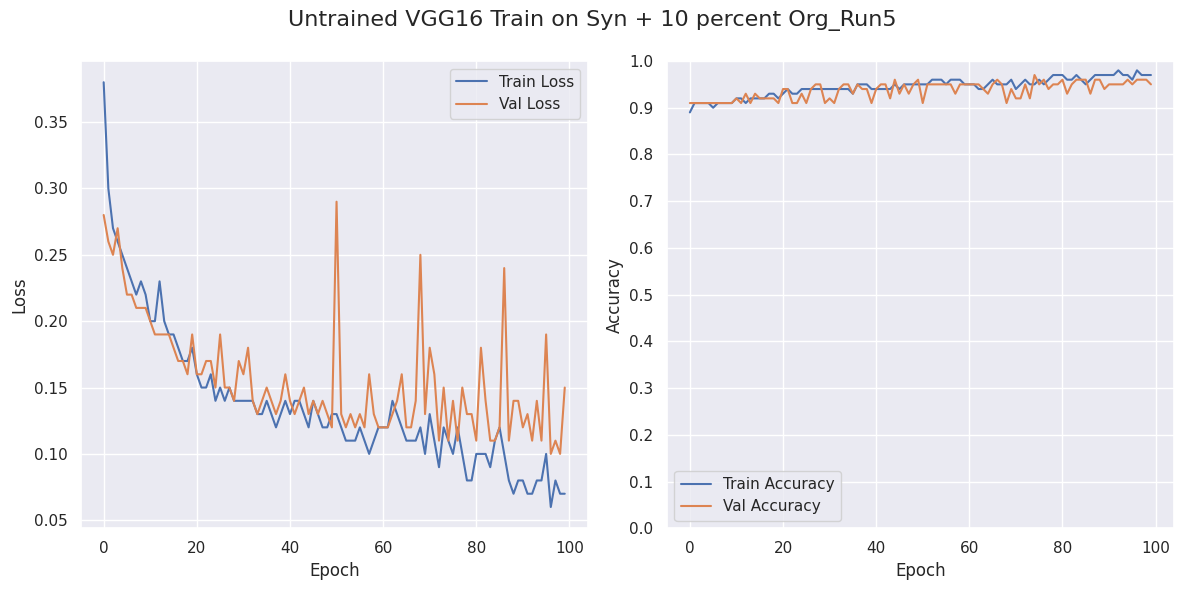

12/12 [==============================] - 3s 211ms/step
{'Test Loss': 1.8348, 'Test Accuracy': 0.6887, 'F1 Score': 0.62, 'Sensitivity (Recall)': 0.69, 'Precision': 0.76, 'Specificity (With Structural Pathology)': 0.2198581560283688}


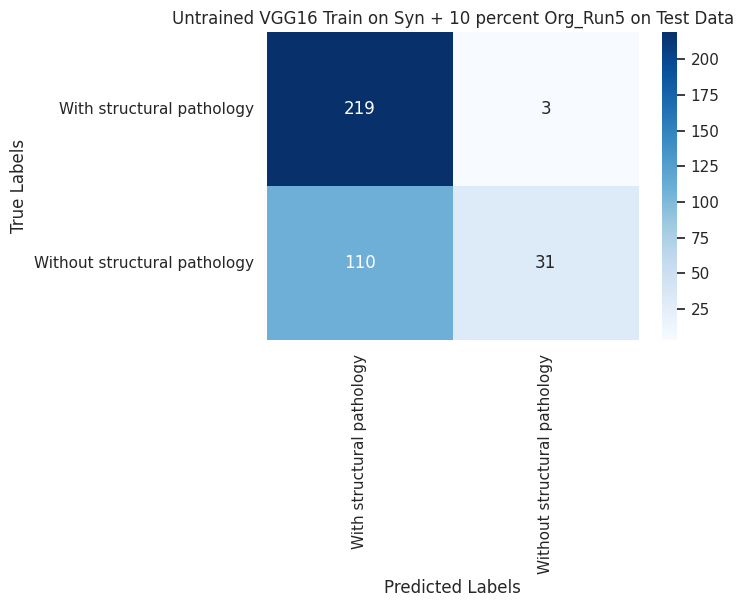

In [5]:
dataset_dir_org = f'{path_dir}/10_percent/Original'
dataset_dir_ddpm = f'{path_dir}/10_percent/Generated'

title = "Untrained VGG16 Train on Syn + 10 percent Org"
file_name = f"{path_dir}/Trained_Models/Untrained_VGG16_Synthetic_10percent_Original.png"

epochs=100
n=5

for i in range(0, n):
    trained_model, test_metrics, confusion_matrix = cv_train_and_evaluate_model(
        dataset_dir_ddpm,
        dataset_dir_org,
        class_labels,
        vgg_model,
        weights=None,
        input_shape=input_shape,
        title=f"{title}_Run{i+1}",
        file_name=file_name,  # Now treated as a keyword argument
        cv=cv,
        epochs=epochs,
        batch_size=batch_size
    )

#### Train on Syn + 50 percent of Original Dataset

Class labels:  ['With structural pathology', 'Without structural pathology']


2024-12-28 21:27:12.544737: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
110/110 [==============================] - 34s 302ms/step - loss: 0.3881 - accuracy: 0.8713 - val_loss: 0.3086 - val_accuracy: 0.8951
Epoch 2/100
110/110 [==============================] - 33s 300ms/step - loss: 0.2916 - accuracy: 0.8933 - val_loss: 0.2683 - val_accuracy: 0.8951
Epoch 3/100
110/110 [==============================] - 33s 301ms/step - loss: 0.2694 - accuracy: 0.8964 - val_loss: 0.2553 - val_accuracy: 0.8951
Epoch 4/100
110/110 [==============================] - 33s 304ms/step - loss: 0.2801 - accuracy: 0.8887 - val_loss: 0.2548 - val_accuracy: 0.8951
Epoch 5/100
110/110 [==============================] - 33s 302ms/step - loss: 0.2606 - accuracy: 0.8944 - val_loss: 0.2984 - val_accuracy: 0.8951
Epoch 6/100
110/110 [==============================] - 33s 304ms/step - loss: 0.2667 - accuracy: 0.8953 - val_loss: 0.2506 - val_accuracy: 0.8951
Epoch 7/100
110/110 [==============================] - 33s 304ms/step - loss: 0.2542 - accuracy: 0.8964 - val_loss: 0.2439 -

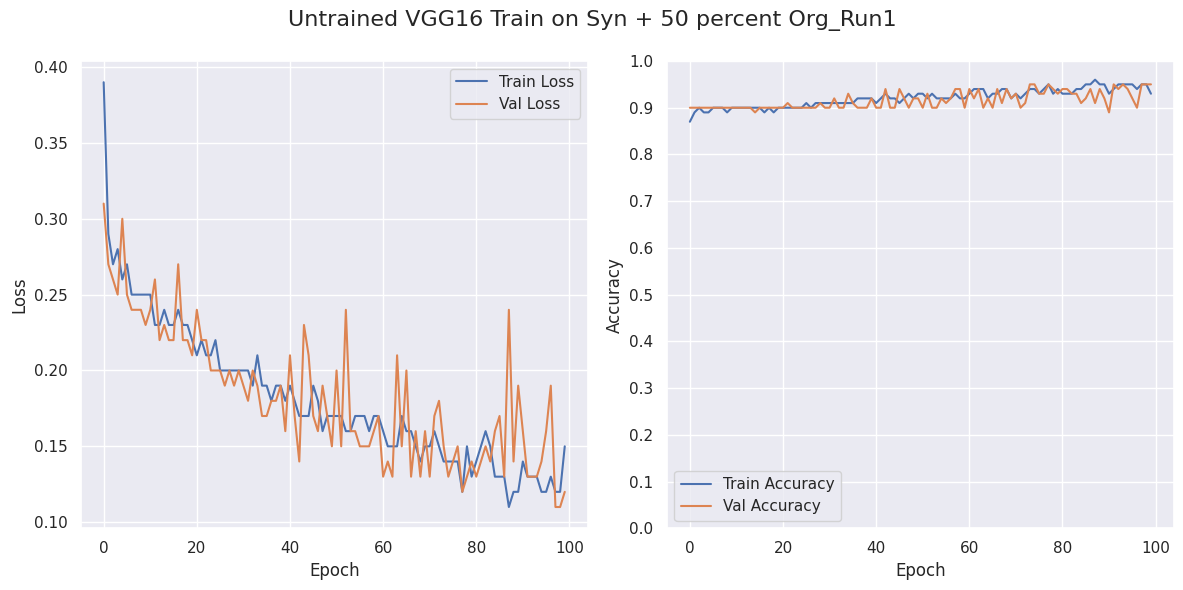

7/7 [==============================] - 2s 203ms/step
{'Test Loss': 0.6858, 'Test Accuracy': 0.7475, 'F1 Score': 0.72, 'Sensitivity (Recall)': 0.75, 'Precision': 0.77, 'Specificity (With Structural Pathology)': 0.43037974683544306}


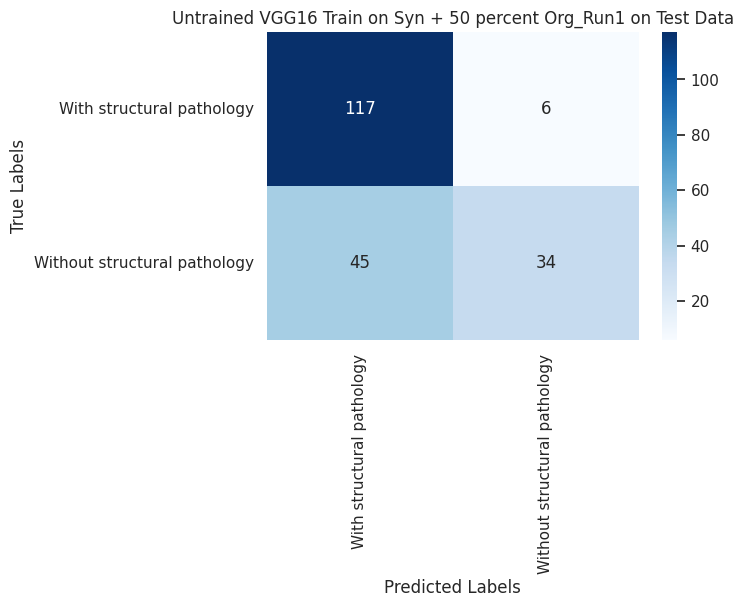

Class labels:  ['With structural pathology', 'Without structural pathology']
Epoch 1/100
110/110 [==============================] - 33s 296ms/step - loss: 0.3860 - accuracy: 0.8702 - val_loss: 0.3095 - val_accuracy: 0.8951
Epoch 2/100
110/110 [==============================] - 33s 297ms/step - loss: 0.2903 - accuracy: 0.8922 - val_loss: 0.2721 - val_accuracy: 0.8951
Epoch 3/100
110/110 [==============================] - 33s 296ms/step - loss: 0.2685 - accuracy: 0.8944 - val_loss: 0.2557 - val_accuracy: 0.8951
Epoch 4/100
110/110 [==============================] - 33s 298ms/step - loss: 0.2775 - accuracy: 0.8913 - val_loss: 0.2529 - val_accuracy: 0.8951
Epoch 5/100
110/110 [==============================] - 33s 299ms/step - loss: 0.2603 - accuracy: 0.8953 - val_loss: 0.2899 - val_accuracy: 0.8951
Epoch 6/100
110/110 [==============================] - 33s 298ms/step - loss: 0.2669 - accuracy: 0.8939 - val_loss: 0.2485 - val_accuracy: 0.8951
Epoch 7/100
110/110 [==========================

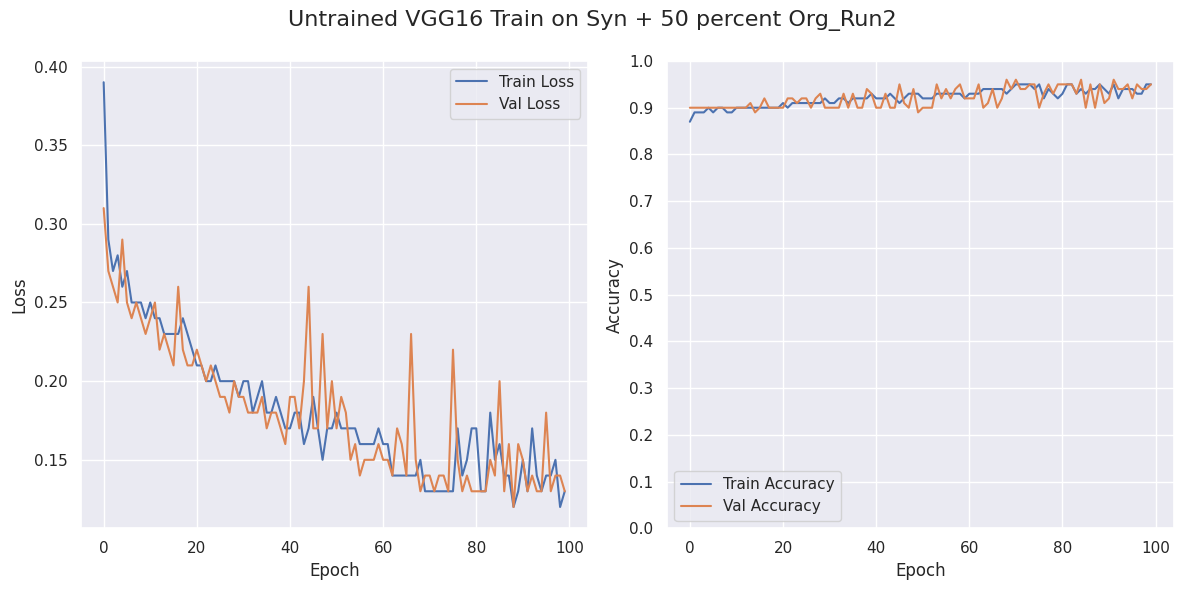

7/7 [==============================] - 2s 196ms/step
{'Test Loss': 0.8242, 'Test Accuracy': 0.7277, 'F1 Score': 0.69, 'Sensitivity (Recall)': 0.73, 'Precision': 0.77, 'Specificity (With Structural Pathology)': 0.35443037974683544}


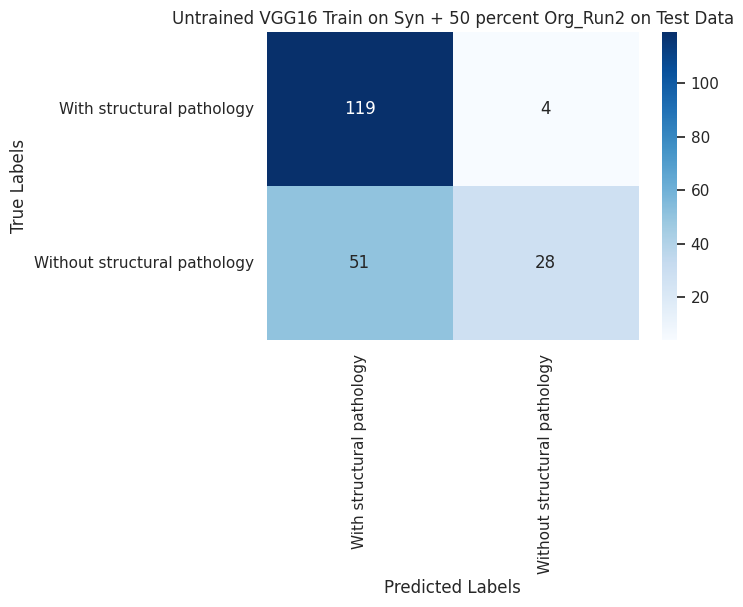

Class labels:  ['With structural pathology', 'Without structural pathology']
Epoch 1/100
110/110 [==============================] - 33s 297ms/step - loss: 0.3954 - accuracy: 0.8725 - val_loss: 0.3139 - val_accuracy: 0.8951
Epoch 2/100
110/110 [==============================] - 33s 297ms/step - loss: 0.2980 - accuracy: 0.8942 - val_loss: 0.2758 - val_accuracy: 0.8951
Epoch 3/100
110/110 [==============================] - 33s 297ms/step - loss: 0.2825 - accuracy: 0.8959 - val_loss: 0.2688 - val_accuracy: 0.8951
Epoch 4/100
110/110 [==============================] - 33s 300ms/step - loss: 0.2945 - accuracy: 0.8922 - val_loss: 0.2658 - val_accuracy: 0.8951
Epoch 5/100
110/110 [==============================] - 33s 298ms/step - loss: 0.2669 - accuracy: 0.8950 - val_loss: 0.2908 - val_accuracy: 0.8951
Epoch 6/100
110/110 [==============================] - 33s 299ms/step - loss: 0.2748 - accuracy: 0.8942 - val_loss: 0.2565 - val_accuracy: 0.8951
Epoch 7/100
110/110 [==========================

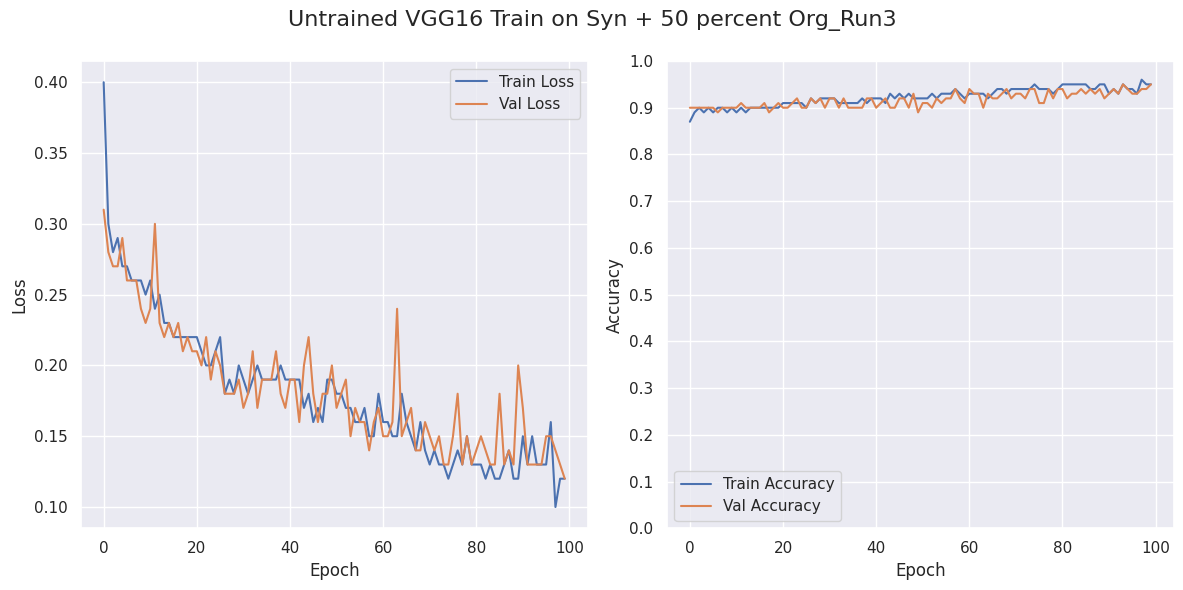

7/7 [==============================] - 2s 199ms/step
{'Test Loss': 0.9418, 'Test Accuracy': 0.7475, 'F1 Score': 0.72, 'Sensitivity (Recall)': 0.75, 'Precision': 0.79, 'Specificity (With Structural Pathology)': 0.3924050632911392}


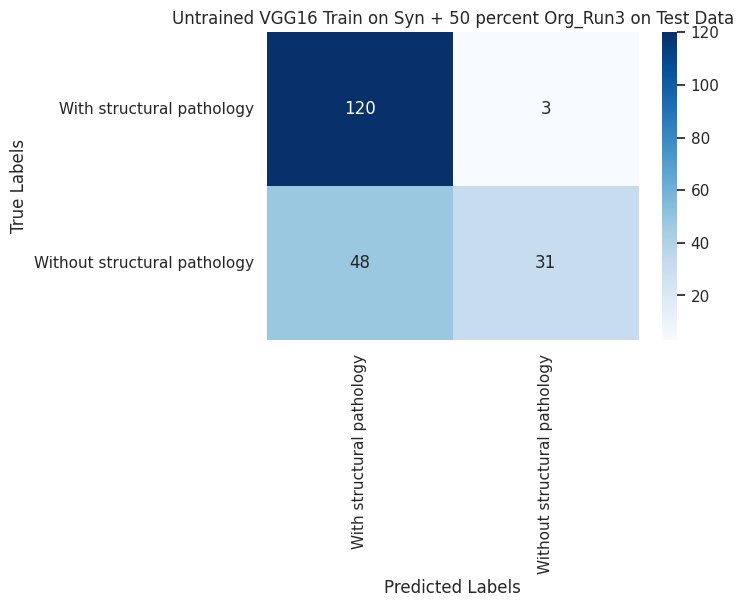

Class labels:  ['With structural pathology', 'Without structural pathology']
Epoch 1/100
110/110 [==============================] - 33s 295ms/step - loss: 0.3812 - accuracy: 0.8730 - val_loss: 0.2930 - val_accuracy: 0.8951
Epoch 2/100
110/110 [==============================] - 33s 297ms/step - loss: 0.2904 - accuracy: 0.8933 - val_loss: 0.2669 - val_accuracy: 0.8951
Epoch 3/100
110/110 [==============================] - 33s 297ms/step - loss: 0.2709 - accuracy: 0.8939 - val_loss: 0.2581 - val_accuracy: 0.8951
Epoch 4/100
110/110 [==============================] - 33s 297ms/step - loss: 0.2803 - accuracy: 0.8942 - val_loss: 0.2522 - val_accuracy: 0.8951
Epoch 5/100
110/110 [==============================] - 33s 299ms/step - loss: 0.2539 - accuracy: 0.8950 - val_loss: 0.2563 - val_accuracy: 0.8951
Epoch 6/100
110/110 [==============================] - 33s 298ms/step - loss: 0.2547 - accuracy: 0.8961 - val_loss: 0.2445 - val_accuracy: 0.8951
Epoch 7/100
110/110 [==========================

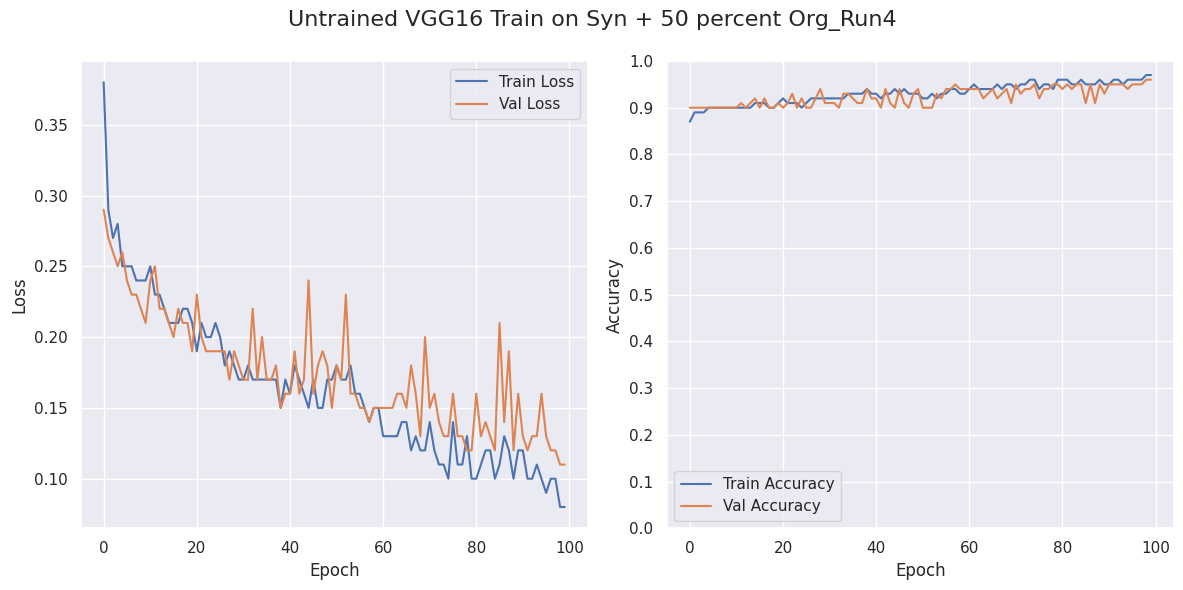

7/7 [==============================] - 2s 200ms/step
{'Test Loss': 0.9813, 'Test Accuracy': 0.7574, 'F1 Score': 0.73, 'Sensitivity (Recall)': 0.76, 'Precision': 0.79, 'Specificity (With Structural Pathology)': 0.43037974683544306}


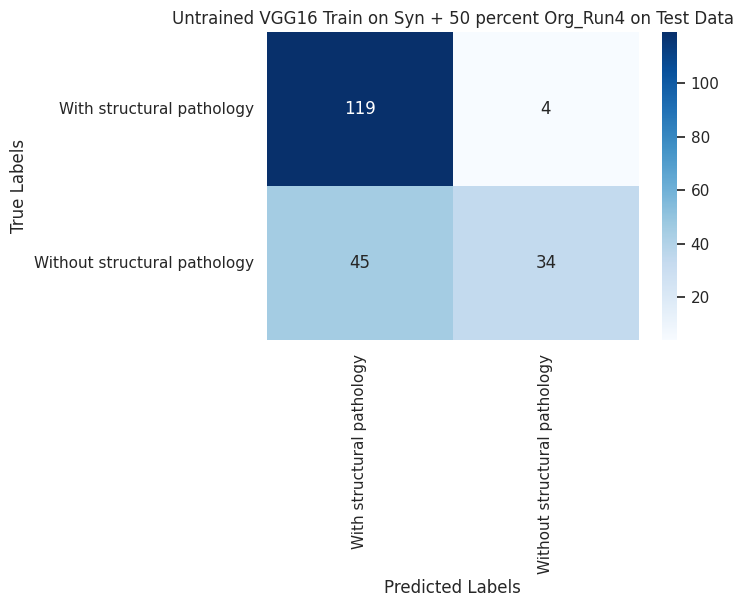

Class labels:  ['With structural pathology', 'Without structural pathology']
Epoch 1/100
110/110 [==============================] - 33s 289ms/step - loss: 0.4315 - accuracy: 0.8676 - val_loss: 0.3161 - val_accuracy: 0.8951
Epoch 2/100
110/110 [==============================] - 32s 292ms/step - loss: 0.3008 - accuracy: 0.8930 - val_loss: 0.2790 - val_accuracy: 0.8951
Epoch 3/100
110/110 [==============================] - 32s 292ms/step - loss: 0.2854 - accuracy: 0.8939 - val_loss: 0.2649 - val_accuracy: 0.8951
Epoch 4/100
110/110 [==============================] - 32s 292ms/step - loss: 0.2903 - accuracy: 0.8930 - val_loss: 0.2656 - val_accuracy: 0.8951
Epoch 5/100
110/110 [==============================] - 32s 293ms/step - loss: 0.2734 - accuracy: 0.8933 - val_loss: 0.2990 - val_accuracy: 0.8951
Epoch 6/100
110/110 [==============================] - 32s 294ms/step - loss: 0.2721 - accuracy: 0.8964 - val_loss: 0.2695 - val_accuracy: 0.8951
Epoch 7/100
110/110 [==========================

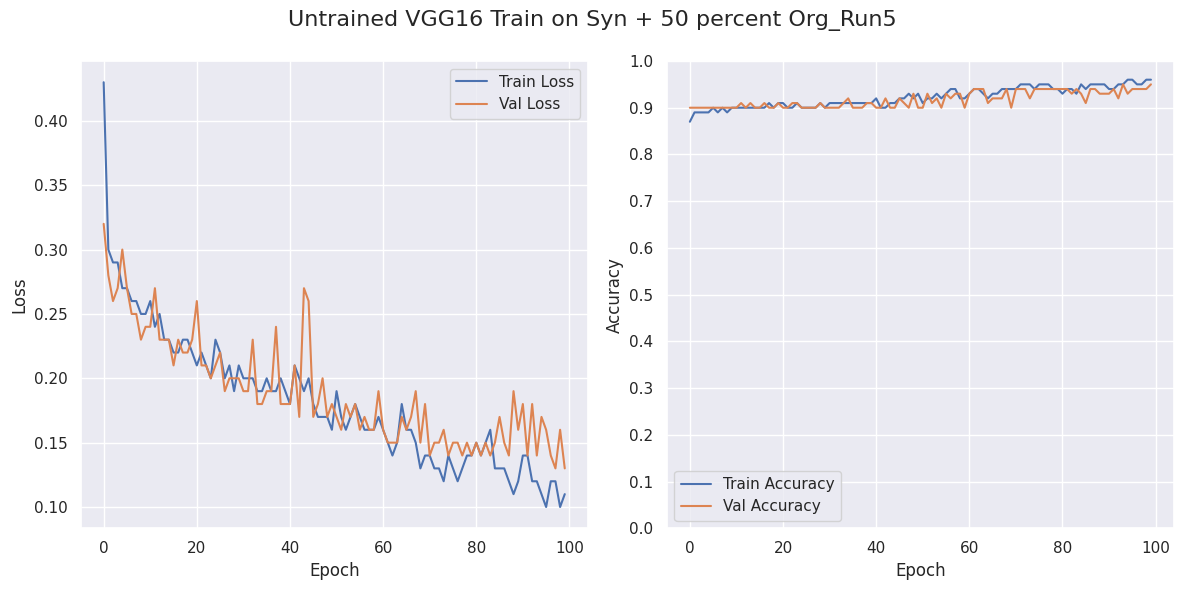

7/7 [==============================] - 2s 201ms/step
{'Test Loss': 0.8787, 'Test Accuracy': 0.7426, 'F1 Score': 0.71, 'Sensitivity (Recall)': 0.74, 'Precision': 0.77, 'Specificity (With Structural Pathology)': 0.4050632911392405}


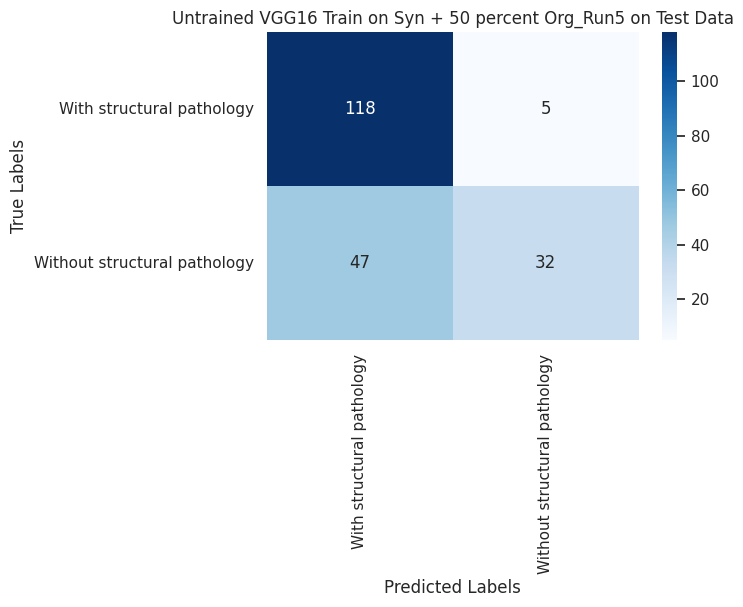

In [5]:
dataset_dir_org = f'{path_dir}/50_percent/Original'
dataset_dir_ddpm = f'{path_dir}/50_percent/Generated'

title = "Untrained VGG16 Train on Syn + 50 percent Org"
file_name = f"{path_dir}/Trained_Models/Untrained_VGG16_Synthetic_50percent_Original.png"

epochs=100
n=5

for i in range(0, n):
    trained_model, test_metrics, confusion_matrix = cv_train_and_evaluate_model(
        dataset_dir_ddpm,
        dataset_dir_org,
        class_labels,
        vgg_model,
        weights=None,
        input_shape=input_shape,
        title=f"{title}_Run{i+1}",
        file_name=file_name,  # Now treated as a keyword argument
        cv=cv,
        epochs=epochs,
        batch_size=batch_size
    )